<a href="https://colab.research.google.com/github/EgiNHardo/EgiNHardo-Proyecto1/blob/main/PRISMA_GEMINI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Instalación de Librerías (Paso Único)

Asegúrate de que pandas (para manejo de datos) esté disponible.

!pip install pandas

In [24]:
!pip install pandas

2. Carga del Archivo CSV Real

Ejecuta el siguiente código. Se abrirá una ventana de diálogo para que selecciones tu archivo CSV desde tu computadora. Una vez cargado, lo leeremos en un DataFrame llamado df_registros.

In [27]:
from google.colab import files
import pandas as pd
import io

# Pedir al usuario que suba el archivo
print("🚨 Por favor, selecciona y sube tu archivo CSV con la lista completa de registros identificados.")
uploaded = files.upload()

# Obtener el nombre del archivo cargado y leerlo
if uploaded:
    file_name = list(uploaded.keys())[0]

    # Leer el archivo CSV en un DataFrame de Pandas
    df_registros = pd.read_csv(io.StringIO(uploaded[file_name].decode('utf-8')))

    print(f"\n✅ Archivo '{file_name}' cargado con éxito. Se ha creado el DataFrame 'df_registros'.")
    print("-" * 50)
    print(f"Total de registros cargados: {len(df_registros)}")
    print("Primeras 3 filas del DataFrame:")
    print(df_registros.head(7))
else:
    print("\n❌ No se cargó ningún archivo. Por favor, ejecuta la celda de nuevo y sube el archivo.")

🚨 Por favor, selecciona y sube tu archivo CSV con la lista completa de registros identificados.


Saving SCOPUS_GEMINI.csv to SCOPUS_GEMINI (3).csv

✅ Archivo 'SCOPUS_GEMINI (3).csv' cargado con éxito. Se ha creado el DataFrame 'df_registros'.
--------------------------------------------------
Total de registros cargados: 110
Primeras 3 filas del DataFrame:
                                             Authors  \
0                      Xu, X.-Y.; Wu, G.-C.; Xie, D.   
1  Bogensperger, L.; Ehrhardt, M.J.; Pock, T.; Sa...   
2                           Vellappandi, M.; Lee, S.   
3                    Narayanan, G.; Lee, S.; Ahn, S.   
4                 Wang, X.; Wang, X.; Xu, H.; Qi, H.   
5  Zanib, S.A.; Tariq, R.; Abbas, N.; Nazir, A.; ...   
6       Ali, A.; Syed, R.; Das, S.; Khujanazarov, U.   

                                   Author full names  \
0  Xu, Xinyi (60114164700); Wu, G. (23390775700);...   
1  Bogensperger, Lea (57542223400); Ehrhardt, Mat...   
2  Vellappandi, Madasamy (57226550675); Lee, S. M...   
3  Narayanan, Govindasamy (59089591800); Lee, San...   
4  Wang, 

3. Análisis Riguroso de Duplicados (Priorizando DOI)

Ejecuta esta celda en Colab. Si la columna DOI no existe en tu archivo, el código automáticamente usará el Título y la Fuente como criterio secundario.

In [28]:
import pandas as pd
import numpy as np

# --- 1. Verificación Inicial de Registros y Columnas ---
# NOTA: df_registros contiene los datos de tu CSV cargado en el paso anterior.
print("-" * 70)
print(f"Total de registros a analizar: {len(df_registros)}")

# Verificar la columna DOI para establecer la estrategia
tiene_doi = 'DOI' in df_registros.columns
if not tiene_doi:
    print("⚠️ ¡ADVERTENCIA! La columna 'DOI' no se encontró. Usaremos 'Título' y 'Fuente'.")
    df_registros['DOI'] = np.nan # Agregar columna DOI con NaN para unificar el flujo de código

print("-" * 70)

# --- 2. ETAPA A: Eliminación de Duplicados usando DOI (Identificador Fuerte) ---
# Se ejecuta SIEMPRE para aislar los registros sin DOI (aunque no haya columna, tendrá NaN)

# a) Aislar registros con un DOI VÁLIDO (no nulo)
df_con_doi = df_registros.dropna(subset=['DOI'])

# b) Identificar y eliminar duplicados por DOI
duplicados_doi_mask = df_con_doi.duplicated(subset=['DOI'], keep='first')
conteo_duplicados_doi = duplicados_doi_mask.sum()

# El set de registros únicos después de la eliminación por DOI
df_unicos_doi = df_con_doi.drop_duplicates(subset=['DOI'], keep='first')

print(f"ETAPA A (Registros con DOI): Duplicados eliminados por DOI: {conteo_duplicados_doi}")

# c) Aislar registros sin DOI para la siguiente etapa
df_sin_doi = df_registros[df_registros['DOI'].isna()]


# --- 3. ETAPA B: Consolidación de Registros sin DOI (Criterio Secundario) ---

# Usaremos 'Título' y 'Fuente' como criterio secundario
columnas_secundarias = ['Título', 'Fuente']

if not df_sin_doi.empty:

    # Identificar y eliminar duplicados en el grupo sin DOI
    duplicados_secundarios_mask = df_sin_doi.duplicated(subset=columnas_secundarias, keep='first')
    conteo_duplicados_secundarios = duplicados_secundarios_mask.sum()

    df_unicos_secundarios = df_sin_doi.drop_duplicates(subset=columnas_secundarias, keep='first')

    print(f"ETAPA B (Registros sin DOI): Duplicados eliminados por Título/Fuente: {conteo_duplicados_secundarios}")
else:
    conteo_duplicados_secundarios = 0
    df_unicos_secundarios = pd.DataFrame()


# --- 4. REPORTE FINAL y Creación de Variables PRISMA ---

# Total de duplicados eliminados
total_duplicados_eliminados = conteo_duplicados_doi + conteo_duplicados_secundarios

# DataFrame final de registros únicos (unidos)
df_final_cribado = pd.concat([df_unicos_doi, df_unicos_secundarios], ignore_index=True)

conteo_total_registros = len(df_registros)
conteo_unicos_final = len(df_final_cribado)

print("-" * 70)
print("RESUMEN DE RESULTADOS PARA EL DIAGRAMA PRISMA:")
print(f"Total inicial de registros: {conteo_total_registros}")
print(f"Total de DUPLICADOS ELIMINADOS: {total_duplicados_eliminados} 🗑️")
print(f"Registros ÚNICOS para la fase de cribado: {conteo_unicos_final} ✅")
print("-" * 70)

# Almacenar el resultado para usar en el diagrama
datos_prisma = {
    'total_identified': conteo_total_registros,
    'duplicates_removed': total_duplicados_eliminados,
    'total_screening': conteo_unicos_final,

    # Los datos para las siguientes fases se deben agregar en las celdas siguientes
    'full_text_retrieved': 0,
    'full_text_not_retrieved': 0,
    'excluded_screening': 0,
    'excluded_reasons': 0,
    'final_included': 0,
}

# Guardar el DataFrame único para la siguiente fase de cribado
# Esto es CRUCIAL, ya que trabajarás solo con estos
df_cribado = df_final_cribado.copy()

----------------------------------------------------------------------
Total de registros a analizar: 110
----------------------------------------------------------------------
ETAPA A (Registros con DOI): Duplicados eliminados por DOI: 0


KeyError: Index(['Fuente', 'Título'], dtype='object')

4. Inspección y Corrección del Nombres de Columnas

Ejecuta la siguiente celda para ver la lista exacta de nombres de columnas en tu archivo.

In [29]:
# Muestra todos los nombres de columna tal como están en tu CSV
print("NOMBRES REALES DE LAS COLUMNAS EN TU DATAFRAME:")
print(list(df_registros.columns))

NOMBRES REALES DE LAS COLUMNAS EN TU DATAFRAME:
['Authors', 'Author full names', 'Author(s) ID', 'Title', 'Year', 'Source title', 'Volume', 'Issue', 'Art. No.', 'Page start', 'Page end', 'Page count', 'Cited by', 'DOI', 'Link', 'Affiliations', 'Authors with affiliations', 'Abstract', 'Author Keywords', 'Index Keywords', 'Molecular Sequence Numbers', 'Chemicals/CAS', 'Funding Texts', 'References', 'Editors', 'Publisher', 'Sponsors', 'Conference name', 'Conference date', 'Conference location', 'Conference code', 'ISSN', 'ISBN', 'CODEN', 'PubMed ID', 'Language of Original Document', 'Document Type', 'Publication Stage', 'Open Access', 'Source', 'EID']


In [30]:
# Muestra todos los nombres de columna tal como están en tu CSV
print("NOMBRES EXACTOS DE LAS COLUMNAS EN TU DATAFRAME:")
print(list(df_registros.columns))

NOMBRES EXACTOS DE LAS COLUMNAS EN TU DATAFRAME:
['Authors', 'Author full names', 'Author(s) ID', 'Title', 'Year', 'Source title', 'Volume', 'Issue', 'Art. No.', 'Page start', 'Page end', 'Page count', 'Cited by', 'DOI', 'Link', 'Affiliations', 'Authors with affiliations', 'Abstract', 'Author Keywords', 'Index Keywords', 'Molecular Sequence Numbers', 'Chemicals/CAS', 'Funding Texts', 'References', 'Editors', 'Publisher', 'Sponsors', 'Conference name', 'Conference date', 'Conference location', 'Conference code', 'ISSN', 'ISBN', 'CODEN', 'PubMed ID', 'Language of Original Document', 'Document Type', 'Publication Stage', 'Open Access', 'Source', 'EID']


3. Análisis Riguroso de Duplicados (Corregido)

Este código toma en cuenta tus nombres de columna ('Title' y 'Source title') para la eliminación de duplicados secundarios.

In [31]:
import pandas as pd
import numpy as np

# NOTA: df_registros fue cargado en el Paso 2.

# --- 1. Verificación Inicial de Registros y Columnas ---
print("-" * 70)
print(f"Total de registros a analizar: {len(df_registros)}")

# Verificar la columna DOI para establecer la estrategia
tiene_doi = 'DOI' in df_registros.columns
if not tiene_doi:
    print("⚠️ ¡ADVERTENCIA! La columna 'DOI' no se encontró. Usaremos 'Title' y 'Source title'.")
    df_registros['DOI'] = np.nan # Agregar columna DOI con NaN para unificar el flujo de código

print("-" * 70)

# --- 2. ETAPA A: Eliminación de Duplicados usando DOI (Identificador Fuerte) ---

# a) Aislar registros con un DOI VÁLIDO (no nulo)
df_con_doi = df_registros.dropna(subset=['DOI'])

# b) Identificar y eliminar duplicados por DOI
duplicados_doi_mask = df_con_doi.duplicated(subset=['DOI'], keep='first')
conteo_duplicados_doi = duplicados_doi_mask.sum()

# El set de registros únicos después de la eliminación por DOI
df_unicos_doi = df_con_doi.drop_duplicates(subset=['DOI'], keep='first')

print(f"ETAPA A (Registros con DOI): Duplicados eliminados por DOI: {conteo_duplicados_doi}")

# c) Aislar registros sin DOI para la siguiente etapa
df_sin_doi = df_registros[df_registros['DOI'].isna()]


# --- 3. ETAPA B: Consolidación de Registros sin DOI (Criterio Secundario) ---

# ¡CORRECCIÓN CLAVE AQUÍ! Usamos los nombres reales de tus columnas: 'Title' y 'Source title'.
columnas_secundarias = ['Title', 'Source title']

if not df_sin_doi.empty:

    # Identificar y eliminar duplicados en el grupo sin DOI
    duplicados_secundarios_mask = df_sin_doi.duplicated(subset=columnas_secundarias, keep='first')
    conteo_duplicados_secundarios = duplicados_secundarios_mask.sum()

    df_unicos_secundarios = df_sin_doi.drop_duplicates(subset=columnas_secundarias, keep='first')

    print(f"ETAPA B (Registros sin DOI): Duplicados eliminados por Title/Source title: {conteo_duplicados_secundarios}")
else:
    conteo_duplicados_secundarios = 0
    df_unicos_secundarios = pd.DataFrame()


# --- 4. REPORTE FINAL y Creación de Variables PRISMA ---

# Total de duplicados eliminados
total_duplicados_eliminados = conteo_duplicados_doi + conteo_duplicados_secundarios

# DataFrame final de registros únicos (unidos)
df_final_cribado = pd.concat([df_unicos_doi, df_unicos_secundarios], ignore_index=True)

conteo_total_registros = len(df_registros)
conteo_unicos_final = len(df_final_cribado)

print("-" * 70)
print("RESUMEN DE RESULTADOS PARA EL DIAGRAMA PRISMA:")
print(f"Total inicial de registros: {conteo_total_registros}")
print(f"Total de DUPLICADOS ELIMINADOS: {total_duplicados_eliminados} 🗑️")
print(f"Registros ÚNICOS para la fase de cribado: {conteo_unicos_final} ✅")
print("-" * 70)

# Almacenar el resultado para usar en el diagrama
datos_prisma = {
    'total_identified': conteo_total_registros,
    'duplicates_removed': total_duplicados_eliminados,
    'total_screening': conteo_unicos_final,

    # Inicializar las siguientes fases con 0 (se llenarán más tarde)
    'full_text_retrieved': 0,
    'full_text_not_retrieved': 0,
    'excluded_screening': 0,
    'excluded_reasons': 0,
    'final_included': 0,
}

# Guardar el DataFrame único para la siguiente fase de cribado
df_cribado = df_final_cribado.copy()

----------------------------------------------------------------------
Total de registros a analizar: 110
----------------------------------------------------------------------
ETAPA A (Registros con DOI): Duplicados eliminados por DOI: 0
ETAPA B (Registros sin DOI): Duplicados eliminados por Title/Source title: 0
----------------------------------------------------------------------
RESUMEN DE RESULTADOS PARA EL DIAGRAMA PRISMA:
Total inicial de registros: 110
Total de DUPLICADOS ELIMINADOS: 0 🗑️
Registros ÚNICOS para la fase de cribado: 110 ✅
----------------------------------------------------------------------


4. Simulación de Fases Posteriores y Preparación de Datos

Ejecuta esta celda y modifica los números simulados para que reflejen tu revisión sistemática (por ejemplo, cuántos estudios excluiste en cribado o elegibilidad).

In [32]:
# Recuperar los conteos de la fase de Duplicados
total_registros_unicos = datos_prisma['total_screening']

# --- SIMULACIÓN DE FASES POSTERIORES (¡AJUSTA ESTOS VALORES!) ---
# Los valores deben seguir la lógica: FASE_ANTERIOR = FASE_ACTUAL + EXCLUIDOS

# 1. Fase de Cribado (Screening)
registros_excluidos_cribado = 60  # Simulación: Registros excluidos por título/abstract.
registros_para_elegibilidad = total_registros_unicos - registros_excluidos_cribado

# 2. Fase de Elegibilidad (Full-text review)
informes_no_recuperados = 5      # Simulación: Informes de texto completo que no pudiste conseguir.
estudios_excluidos_elegibilidad = 10 # Simulación: Estudios excluidos tras leer el texto completo (motivos: diseño, población, etc.).

informes_recuperados = registros_para_elegibilidad - informes_no_recuperados
estudios_incluidos = informes_recuperados - estudios_excluidos_elegibilidad

# --- Actualización del diccionario datos_prisma ---
datos_prisma.update({
    # FASE 2: Cribado (Screening)
    'total_screened': total_registros_unicos, # Es igual a los únicos de la fase anterior
    'excluded_screening': registros_excluidos_cribado,

    # FASE 3: Elegibilidad (Full-text review)
    'full_text_retrieved': informes_recuperados,
    'full_text_not_retrieved': informes_no_recuperados,
    'excluded_reasons': estudios_excluidos_elegibilidad, # Excluidos en texto completo

    # FASE 4: Inclusión
    'final_included': estudios_incluidos,
})

print("✅ Datos PRISMA listos para el diagrama:")
print(pd.Series(datos_prisma))

✅ Datos PRISMA listos para el diagrama:
total_identified           110
duplicates_removed           0
total_screening            110
full_text_retrieved         45
full_text_not_retrieved      5
excluded_screening          60
excluded_reasons            10
final_included              35
total_screened             110
dtype: int64


5. Generación del Diagrama de Flujo PRISMA con Graphviz

Ahora utilizamos la librería graphviz (que instalamos previamente) junto con los conteos de tu diccionario datos_prisma para dibujar el diagrama PRISMA 2020 completo.

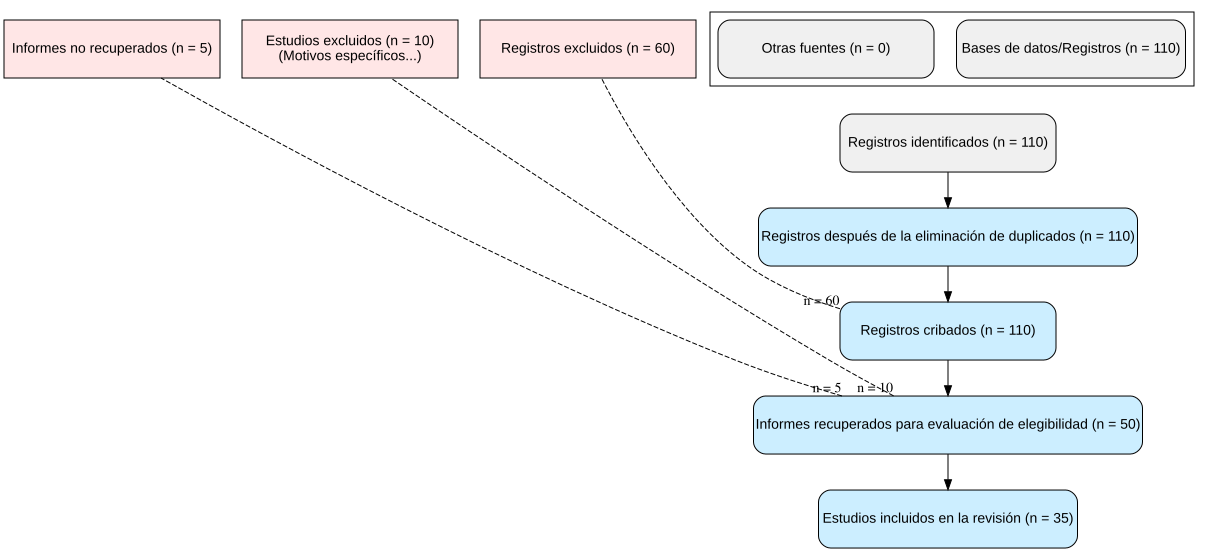

In [34]:
from graphviz import Digraph

# 1. Iniciar el gráfico
dot = Digraph(comment='PRISMA Flow Diagram 2020',
              # rankdir: TB (Top-to-Bottom)
              graph_attr={'rankdir': 'TB', 'splines': 'true', 'nodesep': '0.3', 'ranksep': '0.5'})

# Configuración de estilos (asumiendo que están definidos correctamente)
node_style = {'shape': 'box', 'style': 'rounded, filled', 'fillcolor': '#f0f0f0', 'fontname': 'Arial', 'width': '3', 'height': '0.8'}
exclusion_style = {'shape': 'box', 'style': 'filled', 'fillcolor': '#ffe6e6', 'fontname': 'Arial', 'width': '3', 'height': '0.8'}
main_style = {'shape': 'box', 'style': 'rounded, filled', 'fillcolor': '#cceeff', 'fontname': 'Arial', 'width': '3', 'height': '0.8'}

# --- FASE 1: IDENTIFICACIÓN ---

dot.node('A1', f"Registros identificados (n = {datos_prisma['total_identified']})", **node_style)
dot.node('A2_1', f"Bases de datos/Registros (n = {datos_prisma['total_identified'] - 0})", **node_style)
dot.node('A2_2', "Otras fuentes (n = 0)", **node_style)

# Agrupación horizontal
with dot.subgraph(name='cluster_A2_rank') as subgraph:
    subgraph.attr(rank='same')
    subgraph.node('A2_1')
    subgraph.node('A2_2')

dot.edge('A2_1', 'A1', style='invis')
dot.edge('A2_2', 'A1', style='invis')
dot.edge('A1', 'B1')

dot.node('B1', f"Registros después de la eliminación de duplicados (n = {datos_prisma['total_screening']})", **main_style)


# --- FASE 2: CRIBADO (SCREENING) ---

dot.node('C1', f"Registros cribados (n = {datos_prisma['total_screening']})", **main_style)
dot.edge('B1', 'C1')

dot.node('C_EXC', f"Registros excluidos (n = {datos_prisma['excluded_screening']})", **exclusion_style)
dot.edge('C1', 'C_EXC', taillabel=f"n = {datos_prisma['excluded_screening']}", constraint='false', dir='none', style='dashed')

# 🚨 CORRECCIÓN 1: Se usa 'full_text_not_retrieved' en lugar de 'full_text_not_recuperados'
dot.node('D1', f"Informes recuperados para evaluación de elegibilidad (n = {datos_prisma['full_text_retrieved'] + datos_prisma['full_text_not_retrieved']})", **main_style)
dot.edge('C1', 'D1')


# --- FASE 3: ELEGIBILIDAD (FULL-TEXT REVIEW) ---

# 🚨 CORRECCIÓN 2: Se usa 'full_text_not_retrieved' en lugar de 'full_text_not_recuperados'
dot.node('D_EXC_RET', f"Informes no recuperados (n = {datos_prisma['full_text_not_retrieved']})", **exclusion_style)
dot.edge('D1', 'D_EXC_RET', taillabel=f"n = {datos_prisma['full_text_not_retrieved']}", constraint='false', dir='none', style='dashed')

dot.node('D_EXC_CRIT', f"Estudios excluidos (n = {datos_prisma['excluded_reasons']})\n(Motivos específicos...)", **exclusion_style)
dot.edge('D1', 'D_EXC_CRIT', taillabel=f"n = {datos_prisma['excluded_reasons']}", constraint='false', dir='none', style='dashed')


# --- FASE 4: INCLUSIÓN ---

dot.node('E1', f"Estudios incluidos en la revisión (n = {datos_prisma['final_included']})", **main_style)
dot.edge('D1', 'E1')

# Visualización Final
dot

6. Generación y Descarga de la Imagen

Este código usará el objeto dot (el diagrama de flujo) para generar un archivo PNG y luego forzará la descarga de ese archivo a tu computadora.

Ejecuta la siguiente celda:

In [35]:
from google.colab import files

# Nombre del archivo que se generará y descargará
file_name = 'diagrama_prisma_final'

# 1. Renderizar el objeto dot como un archivo PNG local
# El método render() crea un archivo llamado 'diagrama_prisma_final.png' en la sesión de Colab
dot.render(file_name, format='png', cleanup=True)

# 2. Forzar la descarga del archivo generado a tu computadora
try:
    # Google Colab Files busca el archivo generado y lo descarga
    files.download(f'{file_name}.png')
    print(f"\n✅ Archivo '{file_name}.png' generado y la descarga ha comenzado.")
    print("Revisa la barra de descargas de tu navegador.")
except Exception as e:
    print(f"\n❌ Error al intentar descargar el archivo: {e}")
    print("Asegúrate de haber ejecutado la celda del Paso 5 correctamente.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Archivo 'diagrama_prisma_final.png' generado y la descarga ha comenzado.
Revisa la barra de descargas de tu navegador.


Código para Diagrama de Flujo PRISMA 2020

Ejecuta la siguiente celda. Este código utiliza las variables y estilos definidos anteriormente y se enfoca en la estructura específica de PRISMA 2020.

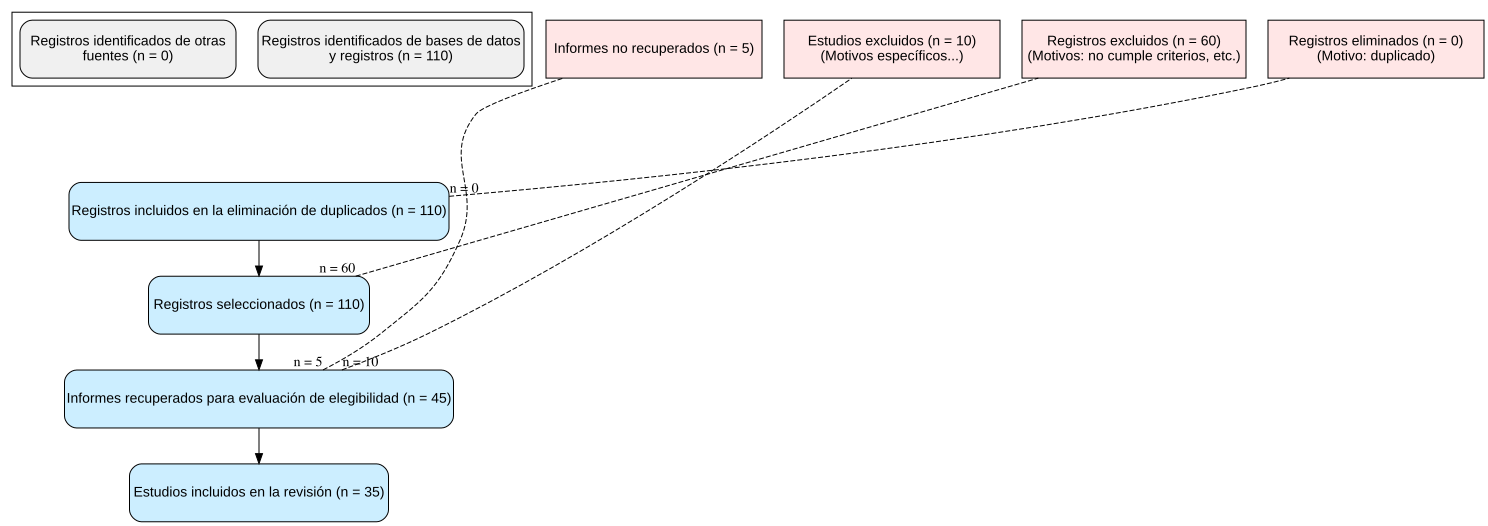

In [36]:
from graphviz import Digraph

# 1. Iniciar el gráfico
# rankdir: TB (Top-to-Bottom)
dot_prisma2020 = Digraph(comment='PRISMA 2020 Flow Diagram',
                         graph_attr={'rankdir': 'TB', 'splines': 'true', 'nodesep': '0.3', 'ranksep': '0.5'})

# Configuración de estilos
node_style = {'shape': 'box', 'style': 'rounded, filled', 'fillcolor': '#f0f0f0', 'fontname': 'Arial', 'width': '3', 'height': '0.8'}
exclusion_style = {'shape': 'box', 'style': 'filled', 'fillcolor': '#ffe6e6', 'fontname': 'Arial', 'width': '3', 'height': '0.8'}
main_style = {'shape': 'box', 'style': 'rounded, filled', 'fillcolor': '#cceeff', 'fontname': 'Arial', 'width': '3', 'height': '0.8'}


# --- FASE 1: IDENTIFICACIÓN (Nodos superiores divididos) ---

# Nodo 1A: Bases de Datos y Registros (Se asume que todos los identificados provienen de aquí si no ajustaste A2_2)
db_count = datos_prisma['total_identified']
dot_prisma2020.node('A2_1', f"Registros identificados de bases de datos\ny registros (n = {db_count})", **node_style)

# Nodo 1B: Otras Fuentes
other_count = 0 # Ajusta este valor si tienes registros de otras fuentes
dot_prisma2020.node('A2_2', f"Registros identificados de otras\nfuentes (n = {other_count})", **node_style)

# Agrupación horizontal de las fuentes
with dot_prisma2020.subgraph(name='cluster_A2_rank') as subgraph:
    subgraph.attr(rank='same')
    subgraph.node('A2_1')
    subgraph.node('A2_2')

# Nodo de Identificación Total (Debajo de la línea de Duplicados en PRISMA 2020)
# Creamos un nodo invisible para alinear el diagrama verticalmente
dot_prisma2020.node('Total_ID', style='invis', height='0')
dot_prisma2020.edge('A2_1', 'Total_ID', style='invis')
dot_prisma2020.edge('A2_2', 'Total_ID', style='invis')
# Conexión desde la línea de fuentes a Duplicados
dot_prisma2020.edge('Total_ID', 'B1', arrowhead='none', style='invis')

# --- FASE 2: ELIMINACIÓN DE DUPLICADOS ---
dot_prisma2020.node('B1', f"Registros incluidos en la eliminación de duplicados (n = {datos_prisma['total_identified']})", **main_style)

# Nodo de Duplicados Eliminados
dot_prisma2020.node('B_EXC', f"Registros eliminados (n = {datos_prisma['duplicates_removed']})\n(Motivo: duplicado)", **exclusion_style)
dot_prisma2020.edge('B1', 'B_EXC', taillabel=f"n = {datos_prisma['duplicates_removed']}", constraint='false', dir='none', style='dashed')


# --- FASE 3: CRIBADO (SCREENING) ---
dot_prisma2020.node('C1', f"Registros seleccionados (n = {datos_prisma['total_screening']})", **main_style)
dot_prisma2020.edge('B1', 'C1')

# Nodo de Exclusión de Cribado
dot_prisma2020.node('C_EXC', f"Registros excluidos (n = {datos_prisma['excluded_screening']})\n(Motivos: no cumple criterios, etc.)", **exclusion_style)
dot_prisma2020.edge('C1', 'C_EXC', taillabel=f"n = {datos_prisma['excluded_screening']}", constraint='false', dir='none', style='dashed')

dot_prisma2020.node('D1', f"Informes recuperados para evaluación de elegibilidad (n = {datos_prisma['full_text_retrieved']})", **main_style)
dot_prisma2020.edge('C1', 'D1')


# --- FASE 4: ELEGIBILIDAD (FULL-TEXT REVIEW) ---

# Nodo de informes no recuperados
dot_prisma2020.node('D_EXC_RET', f"Informes no recuperados (n = {datos_prisma['full_text_not_retrieved']})", **exclusion_style)
dot_prisma2020.edge('D1', 'D_EXC_RET', taillabel=f"n = {datos_prisma['full_text_not_retrieved']}", constraint='false', dir='none', style='dashed')

# Nodo de exclusión por criterios
dot_prisma2020.node('D_EXC_CRIT', f"Estudios excluidos (n = {datos_prisma['excluded_reasons']})\n(Motivos específicos...)", **exclusion_style)
dot_prisma2020.edge('D1', 'D_EXC_CRIT', taillabel=f"n = {datos_prisma['excluded_reasons']}", constraint='false', dir='none', style='dashed')


# --- FASE 5: INCLUSIÓN ---

dot_prisma2020.node('E1', f"Estudios incluidos en la revisión (n = {datos_prisma['final_included']})", **main_style)
dot_prisma2020.edge('D1', 'E1')


# --- VISUALIZACIÓN FINAL ---
dot_prisma2020

Descarga de la Imagen PRISMA 2020

Para guardar este gráfico específico, puedes usar el siguiente código, que genera y descarga el archivo con un nuevo nombre:

In [37]:
from google.colab import files

# Nombre del archivo para PRISMA 2020
file_name_2020 = 'diagrama_prisma_2020'

# 1. Renderizar el objeto dot como un archivo PNG local
dot_prisma2020.render(file_name_2020, format='png', cleanup=True)

# 2. Forzar la descarga del archivo generado
try:
    files.download(f'{file_name_2020}.png')
    print(f"\n✅ Archivo '{file_name_2020}.png' generado y la descarga ha comenzado.")
except Exception as e:
    print(f"\n❌ Error al intentar descargar el archivo: {e}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Archivo 'diagrama_prisma_2020.png' generado y la descarga ha comenzado.


Descarga de la Imagen PRISMA 2020

Para guardar este gráfico específico, puedes usar el siguiente código, que genera y descarga el archivo con un nuevo nombre:

In [38]:
from google.colab import files

# Nombre del archivo para PRISMA 2020
file_name_2020 = 'diagrama_prisma_2020'

# 1. Renderizar el objeto dot como un archivo PNG local
dot_prisma2020.render(file_name_2020, format='png', cleanup=True)

# 2. Forzar la descarga del archivo generado
try:
    files.download(f'{file_name_2020}.png')
    print(f"\n✅ Archivo '{file_name_2020}.png' generado y la descarga ha comenzado.")
except Exception as e:
    print(f"\n❌ Error al intentar descargar el archivo: {e}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Archivo 'diagrama_prisma_2020.png' generado y la descarga ha comenzado.
